In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
cols = pd.read_csv("../data/census-bureau.columns", header = None)[0].tolist()
df = pd.read_csv("../data/census-bureau.data", names = cols)

# Exploratory Data Analysis (EDA)

In [ ]:
df.head()

In [21]:
df.describe()

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


In [35]:
exclude_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "veterans benefits",
    "own business or self employed",
    "year"
]

num_cols = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_cols
]

# including only the numeric columns for outlier analysis (the ones excluded are categorical columns encoded as numeric)

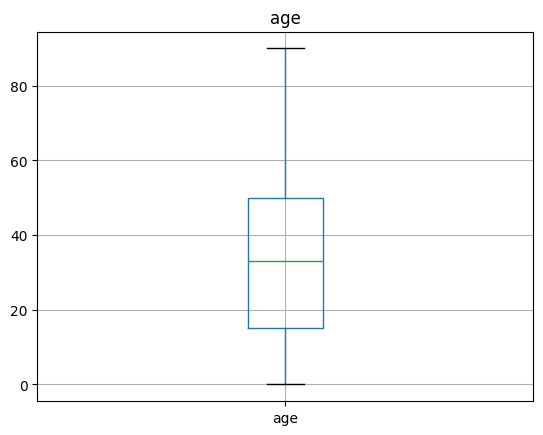

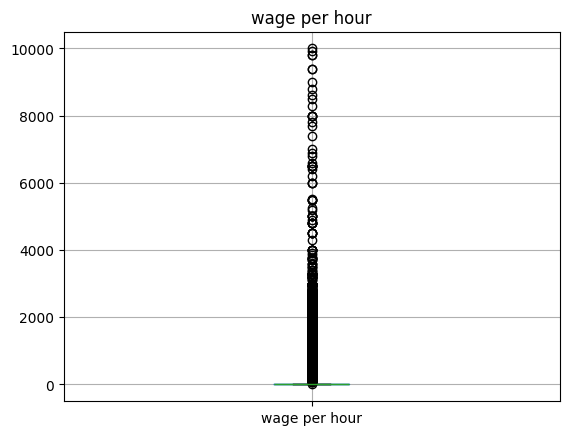

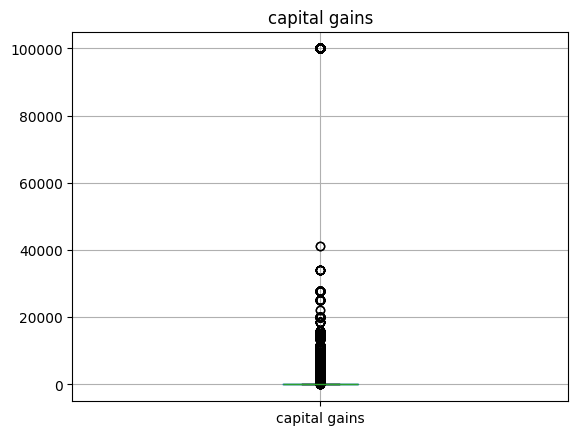

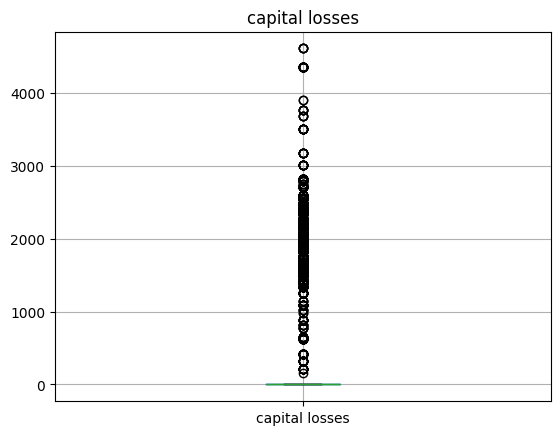

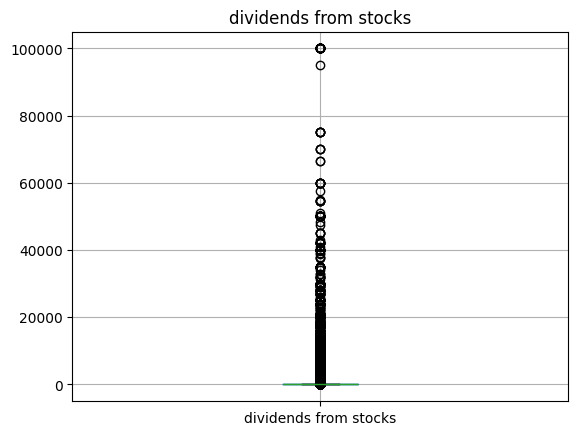

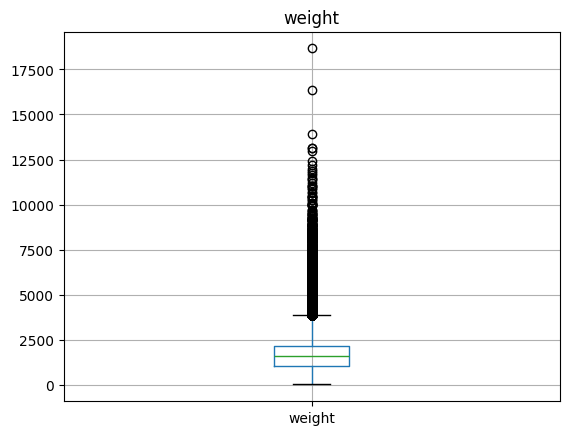

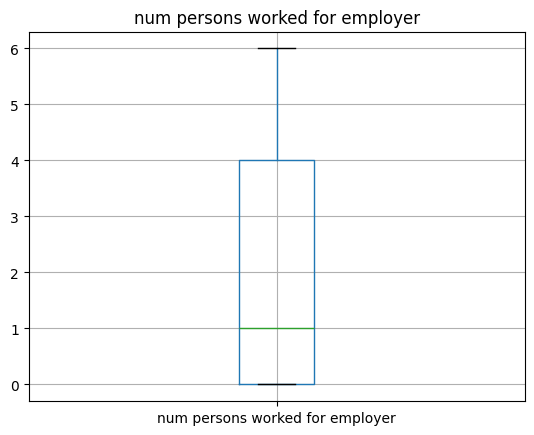

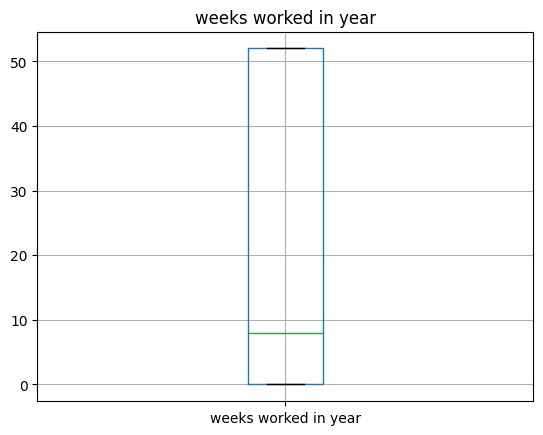

In [36]:
for col in num_cols:
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

In [ ]:
df["label"].value_counts()  # looking at the class distribution

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [ ]:
df["label"] = df["label"].map({
    "- 50000.": 0,
    "50000+.": 1
})  # encoding labels to 0 and 1

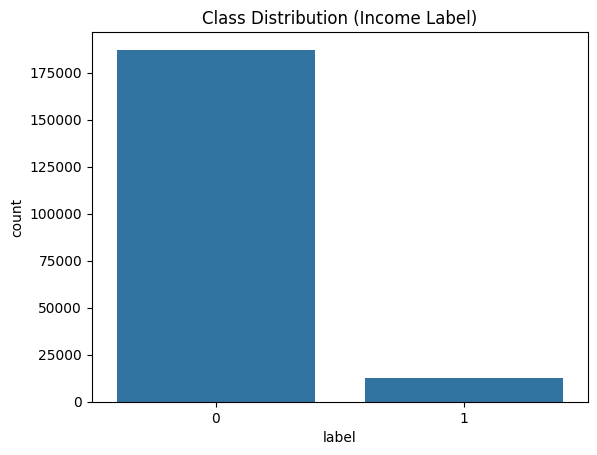

In [46]:
sns.countplot(x="label", data=df)
plt.title("Class Distribution (Income Label)")
plt.show()

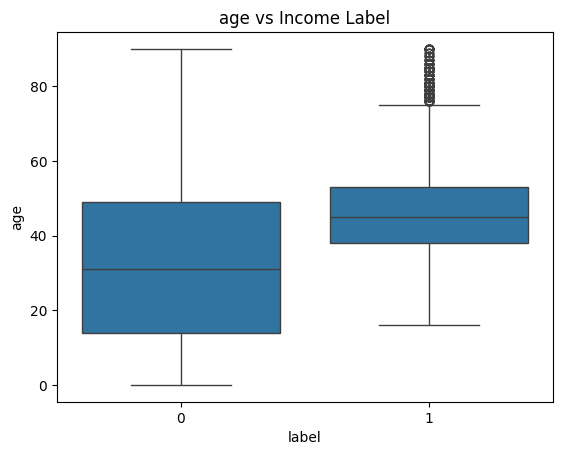

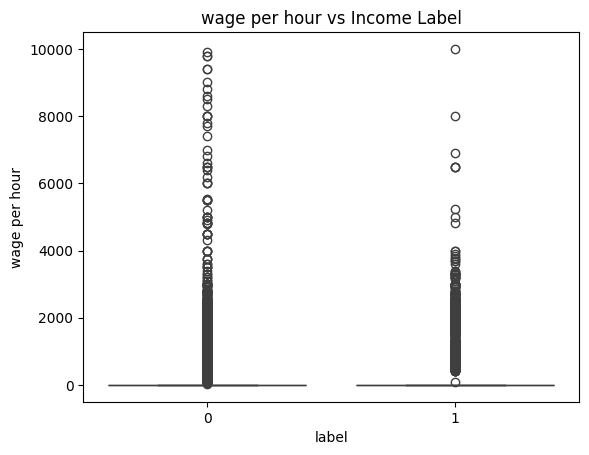

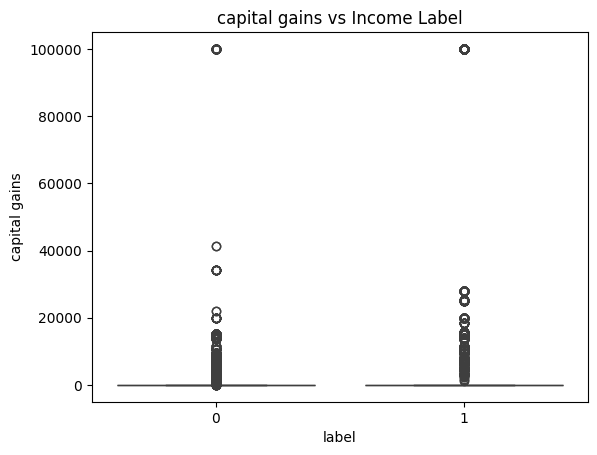

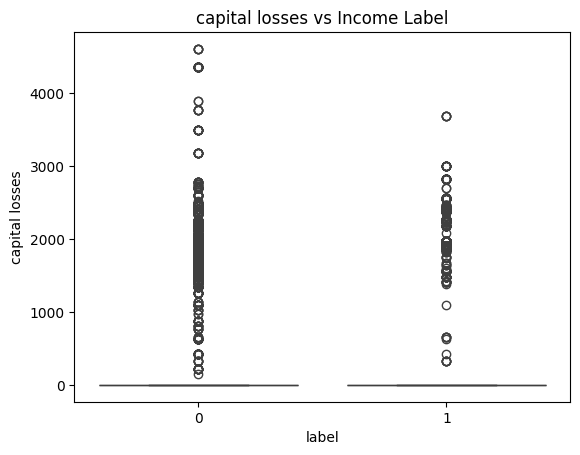

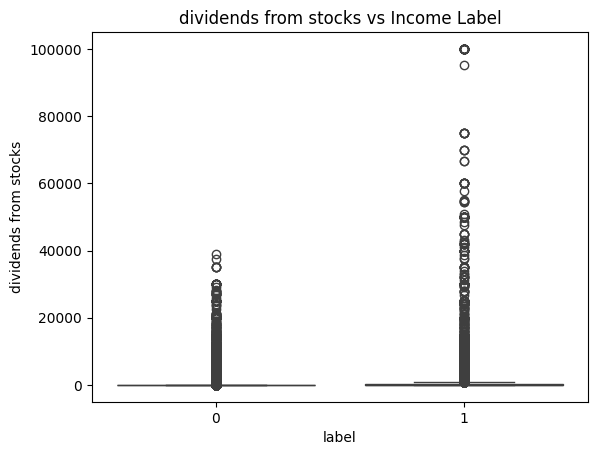

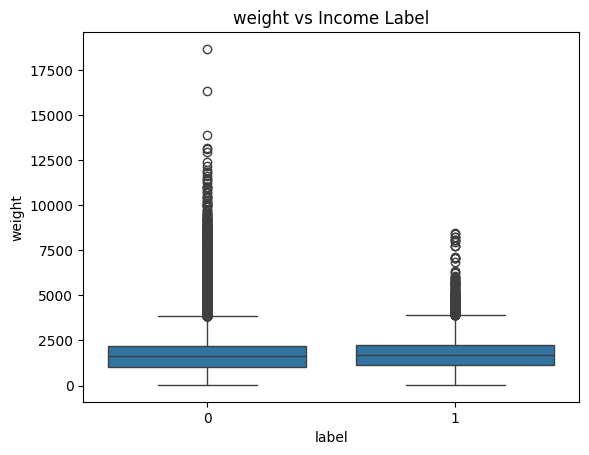

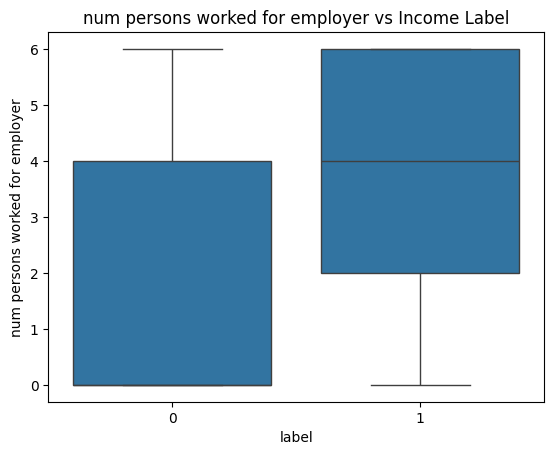

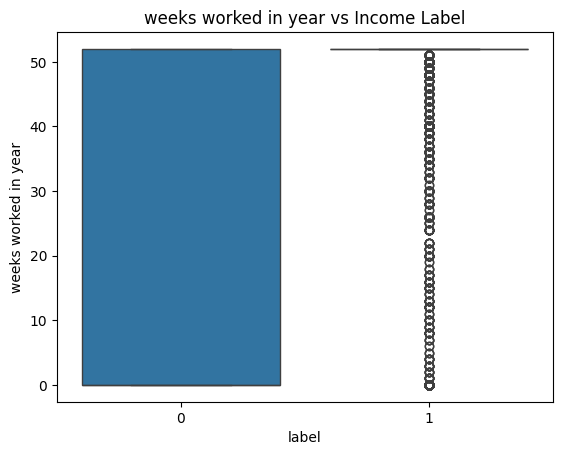

In [47]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x="label", y=col, data=df)
    plt.title(f"{col} vs Income Label")
    plt.show()

In [51]:
categorical_cols = [col for col in df.columns if col not in num_cols + ["label"]]

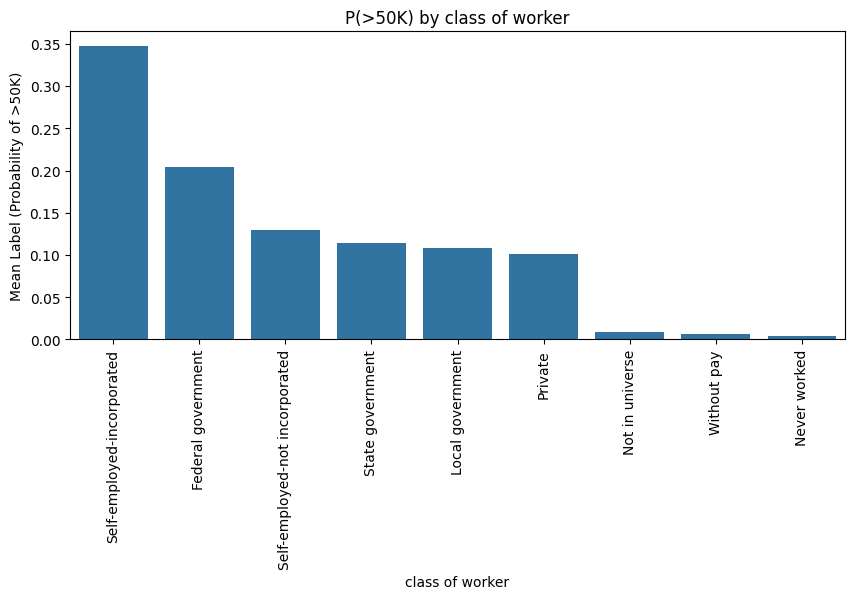

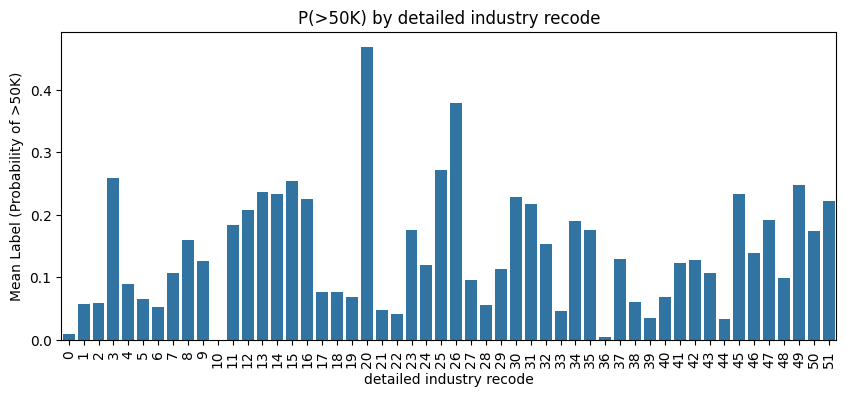

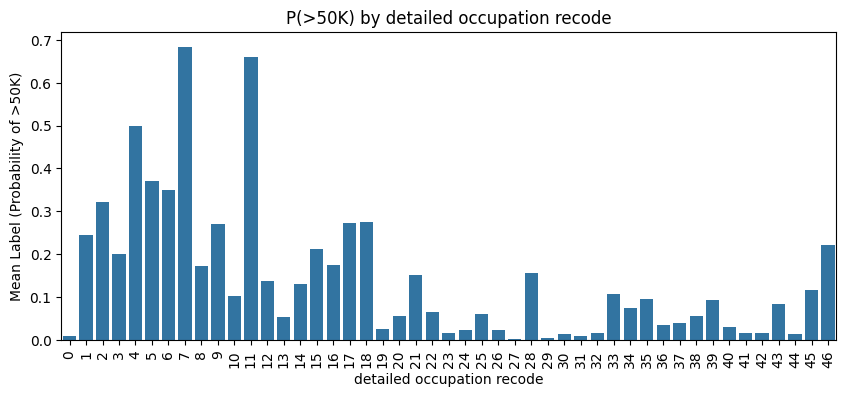

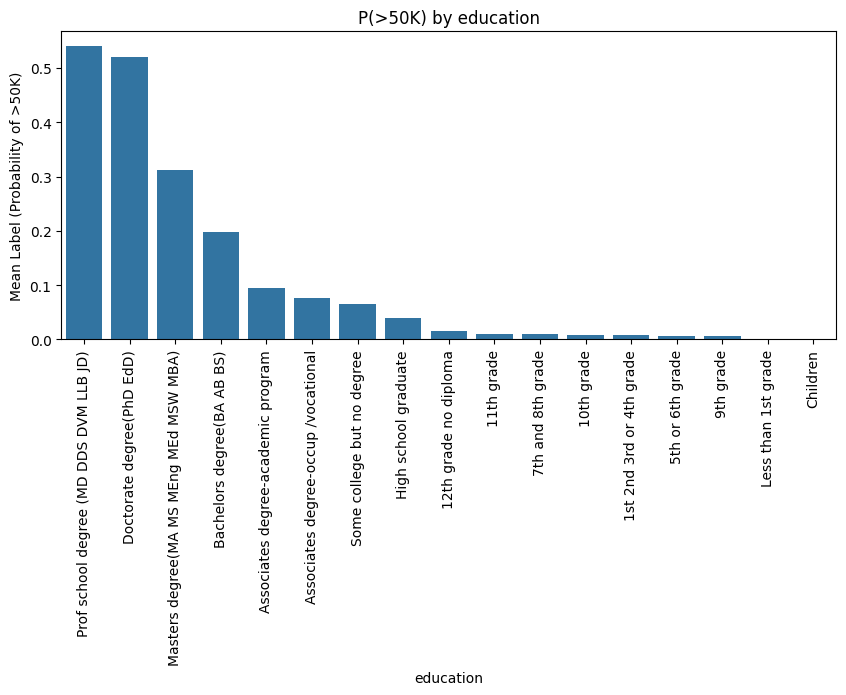

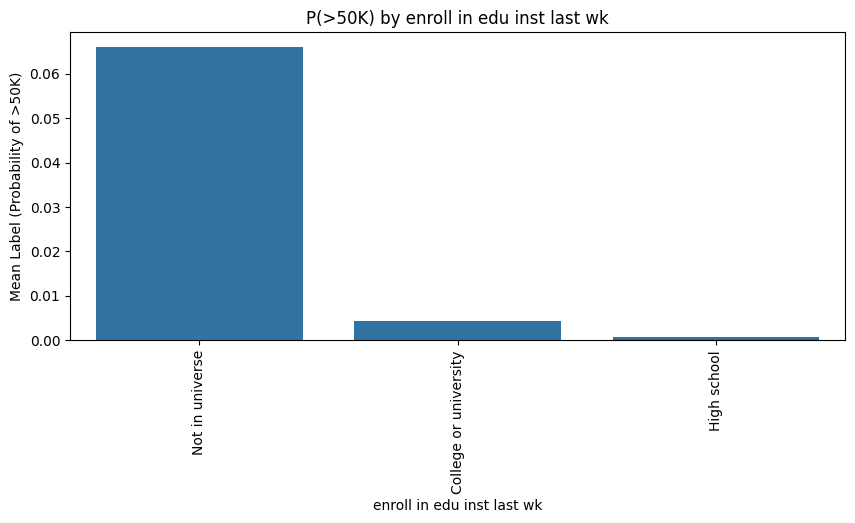

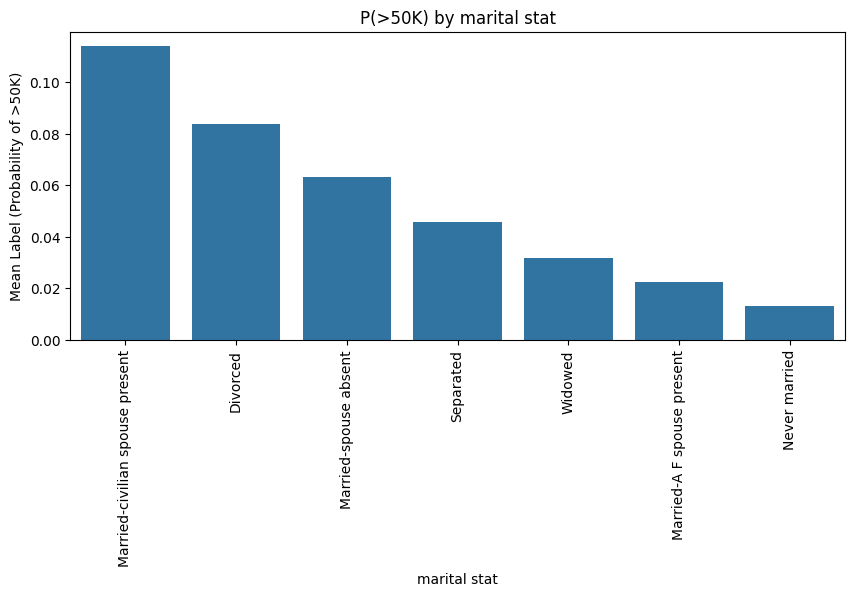

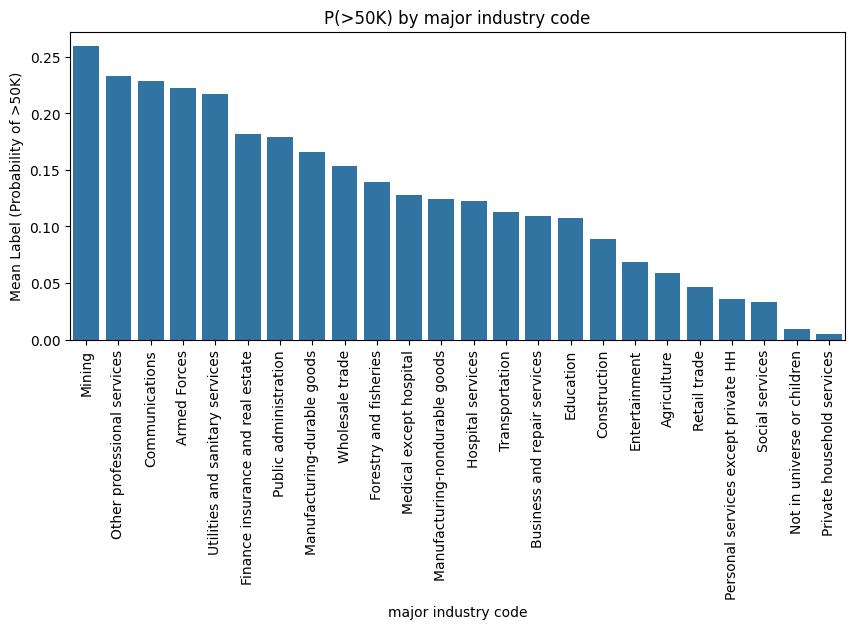

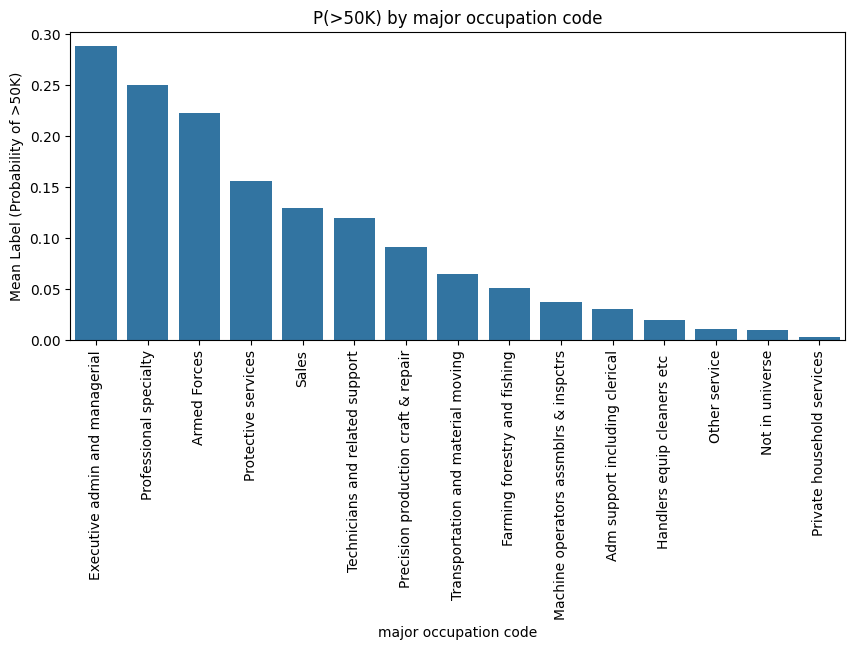

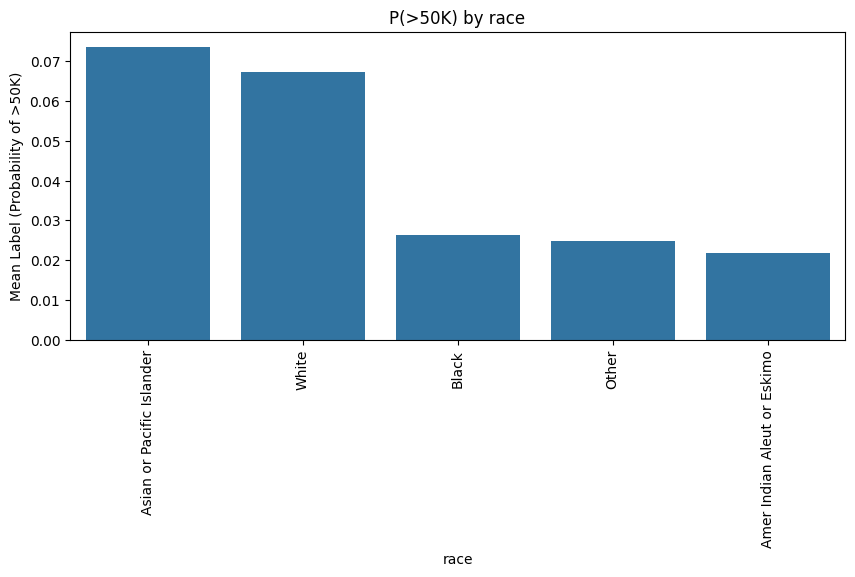

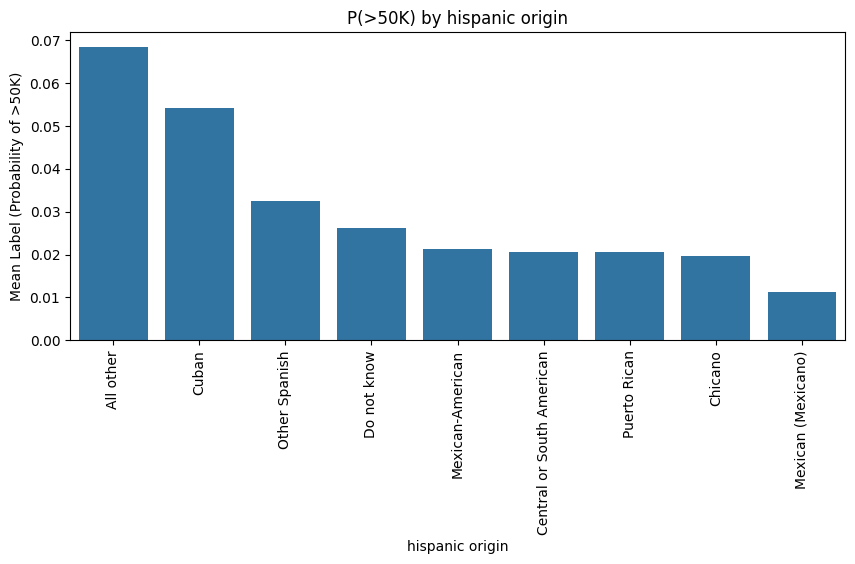

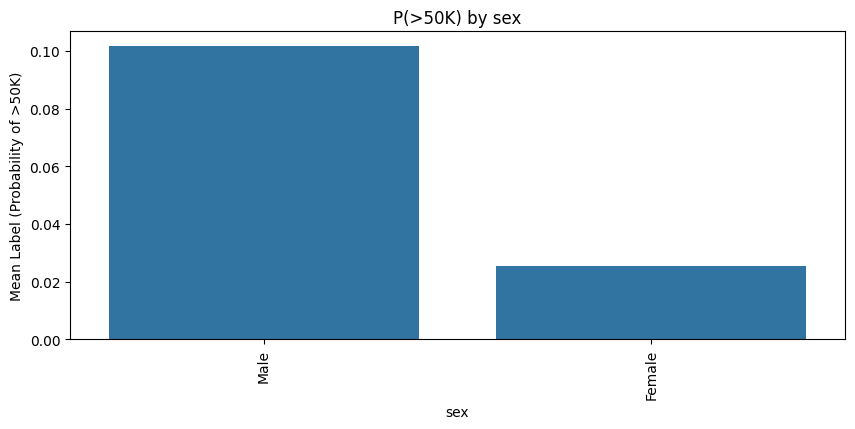

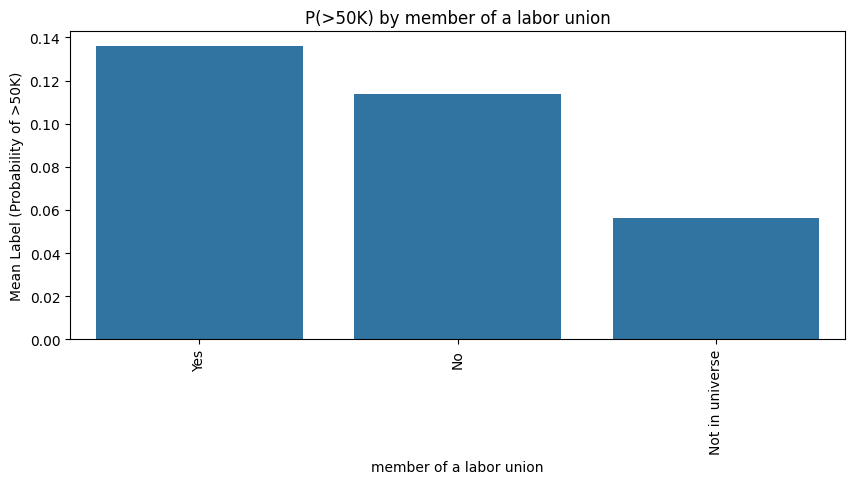

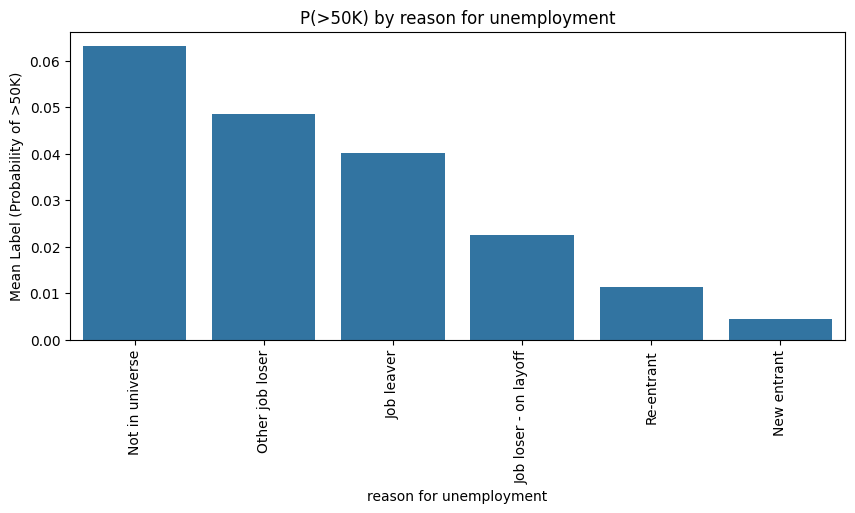

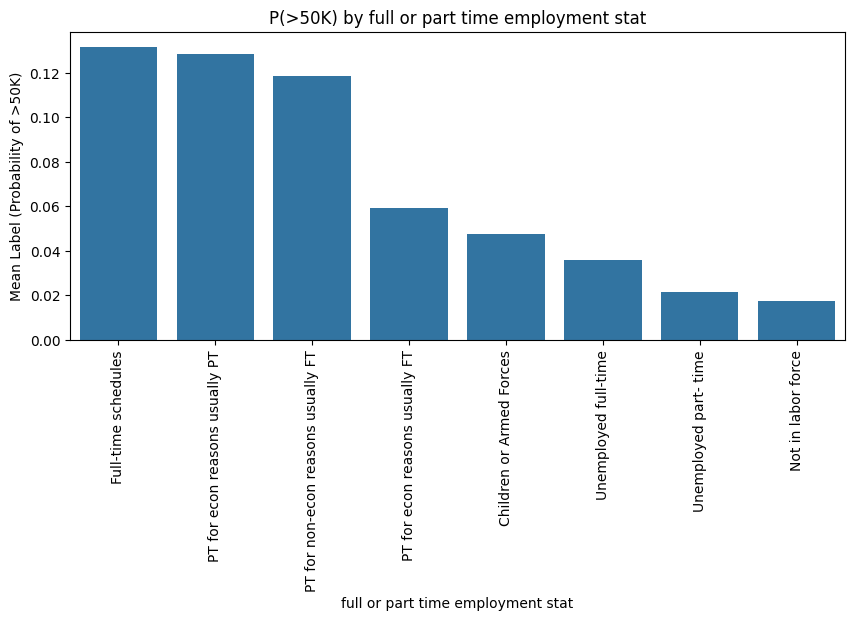

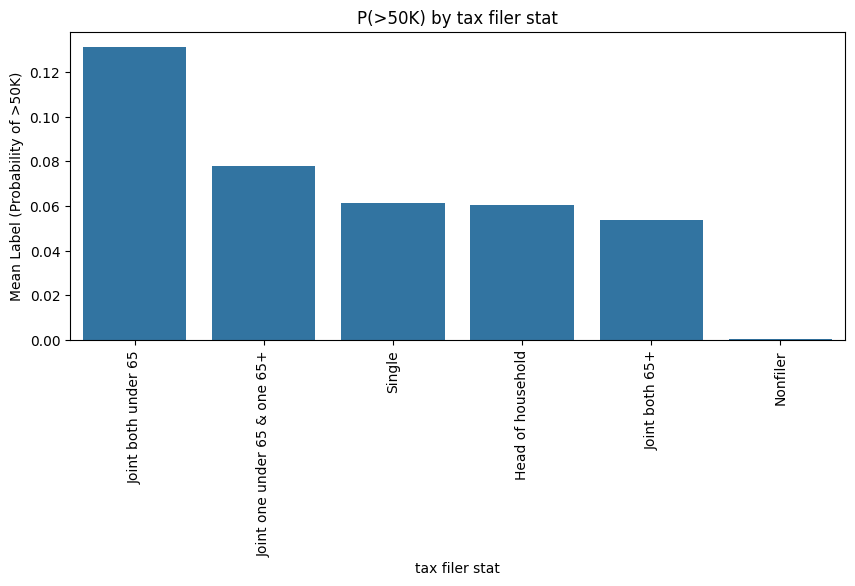

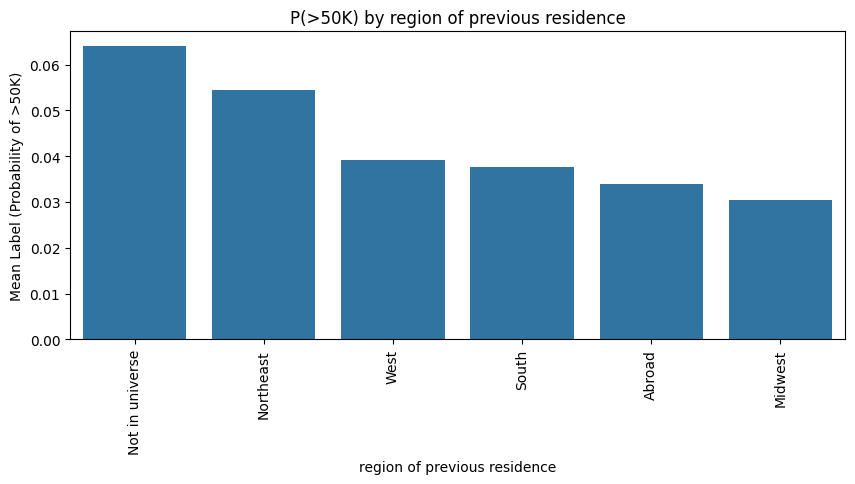

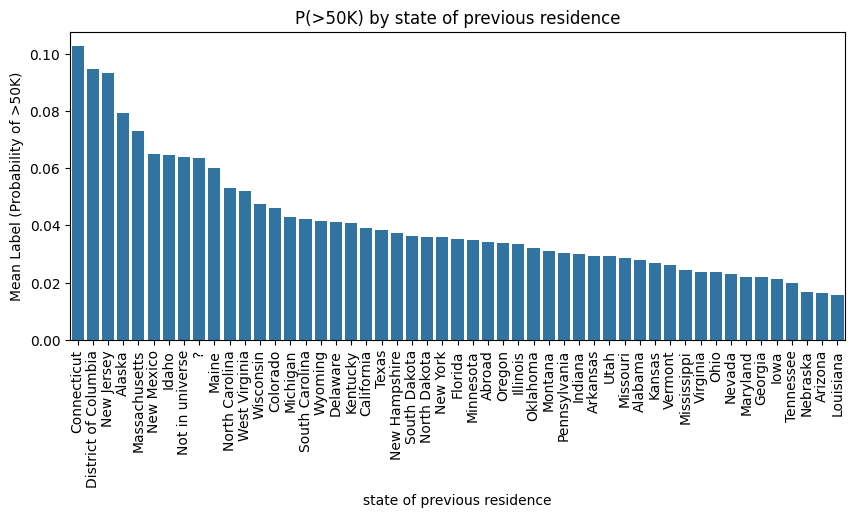

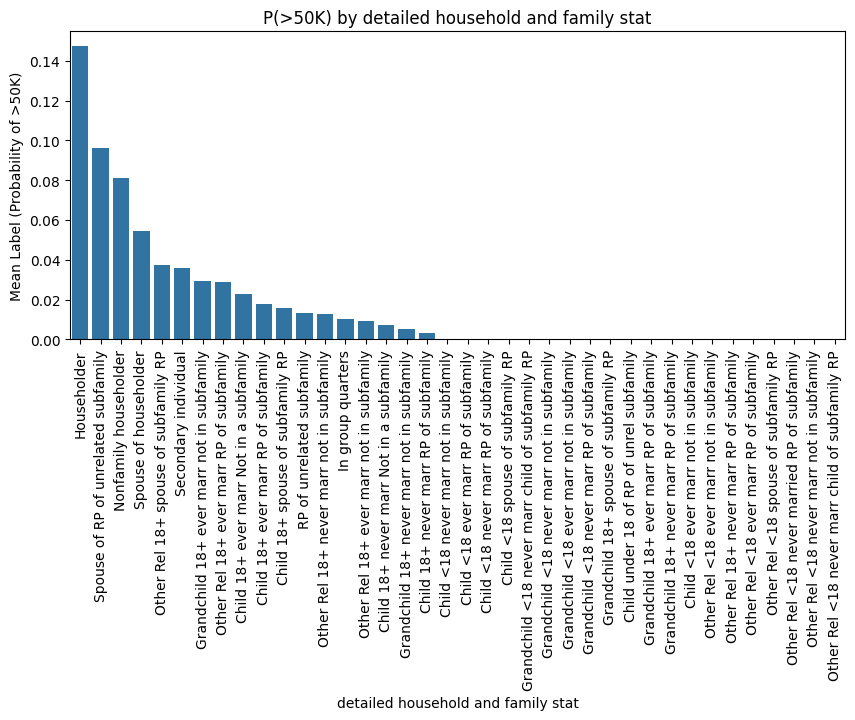

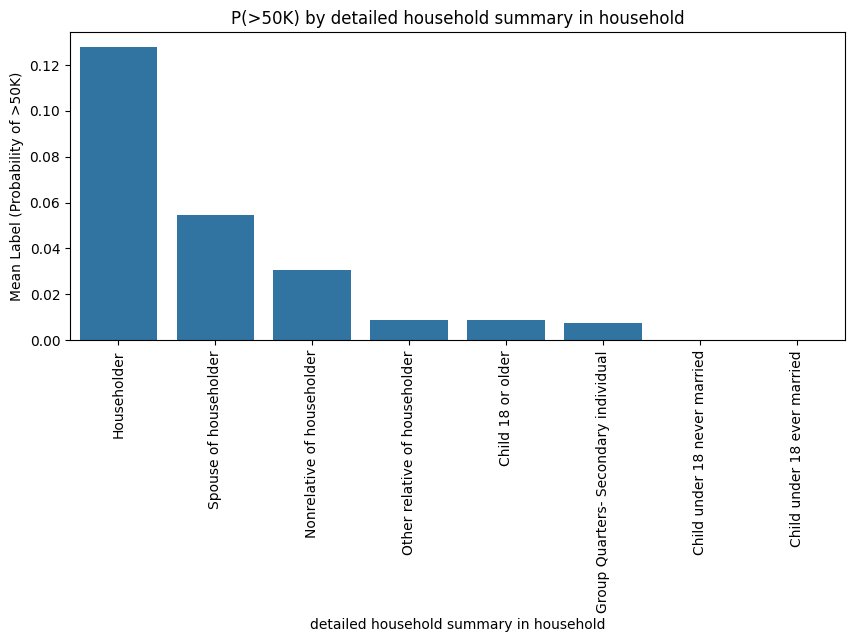

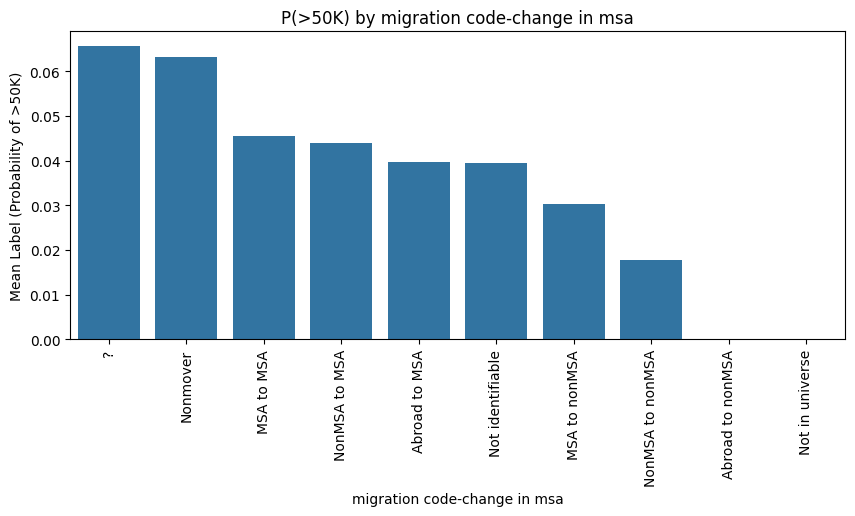

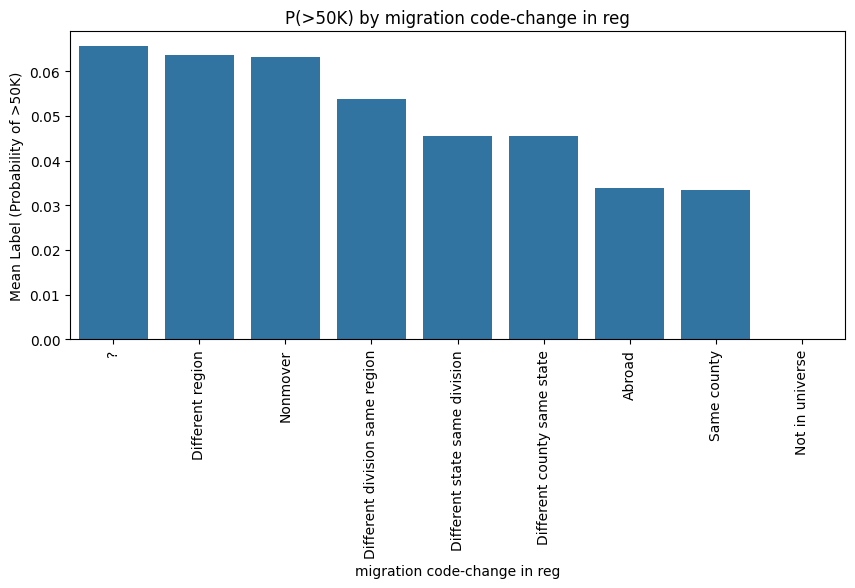

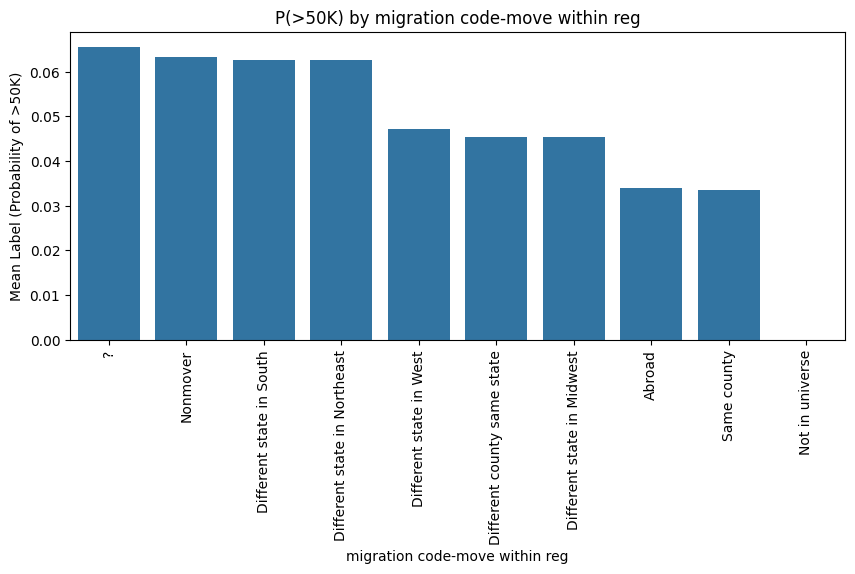

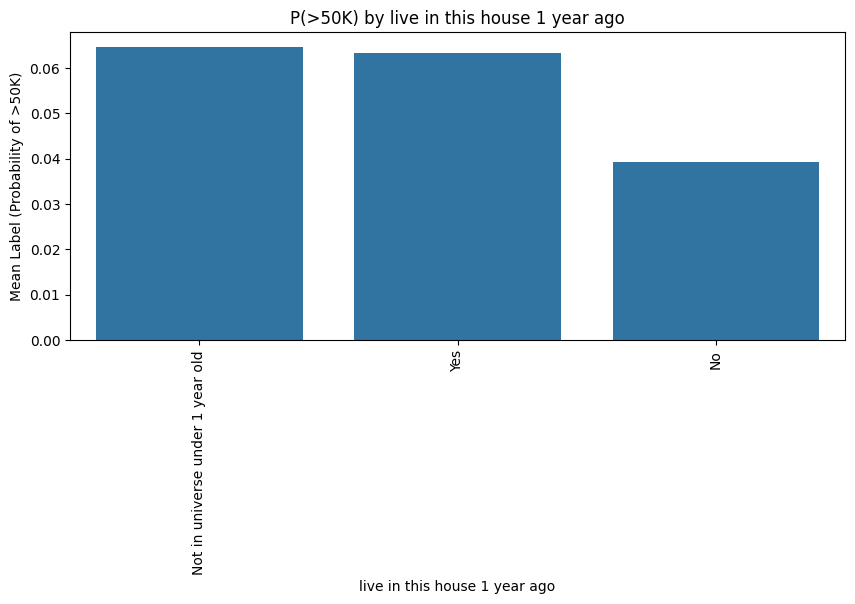

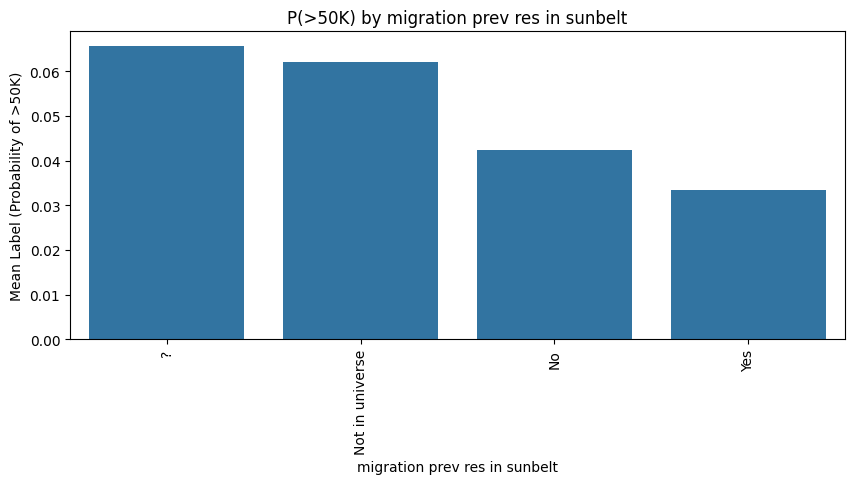

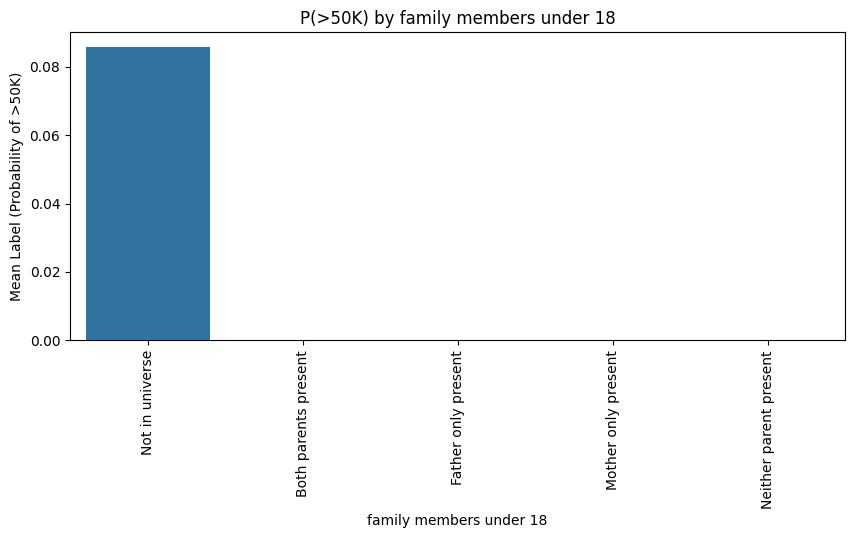

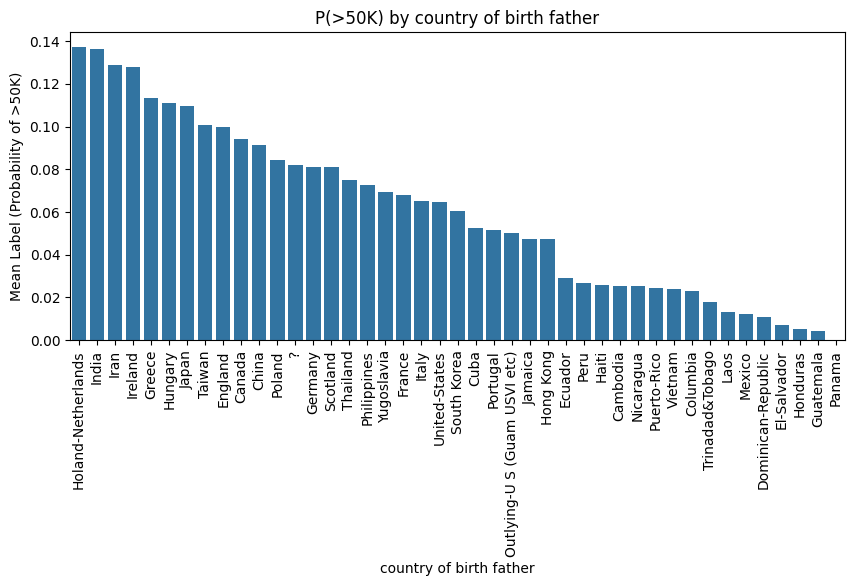

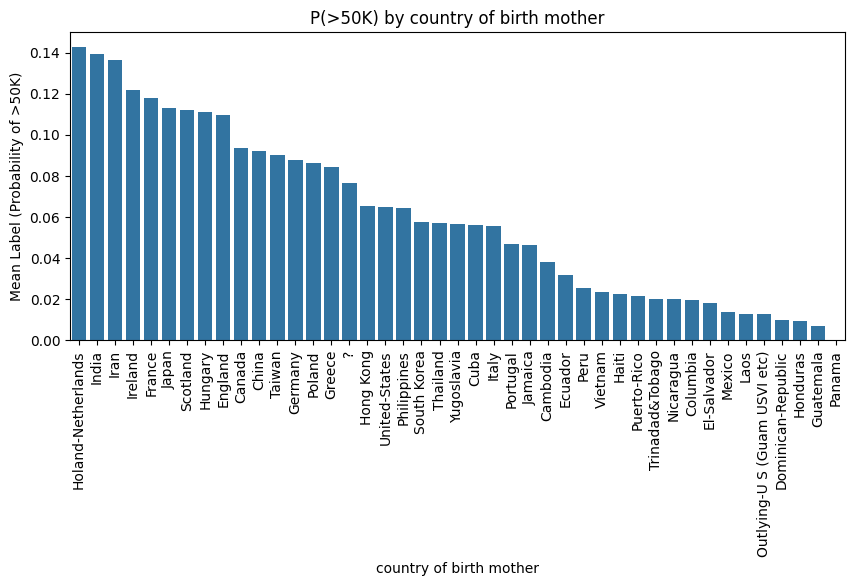

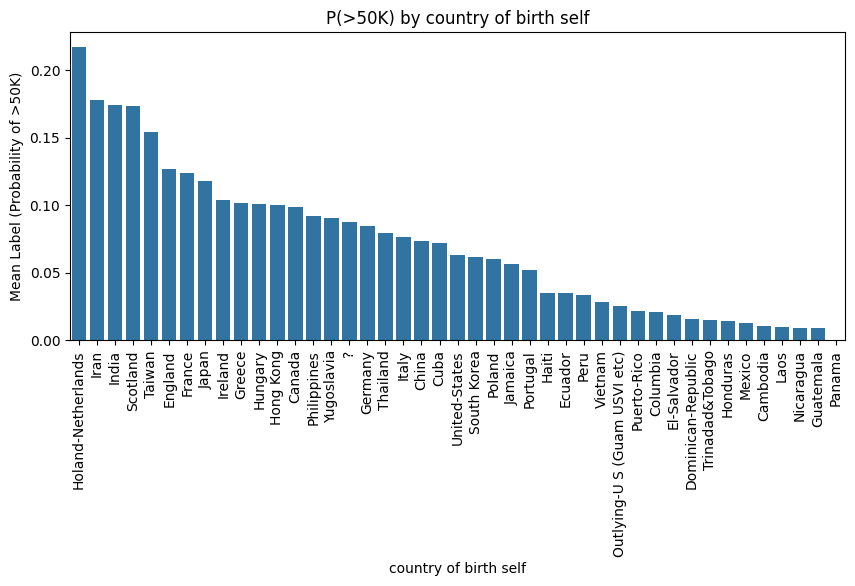

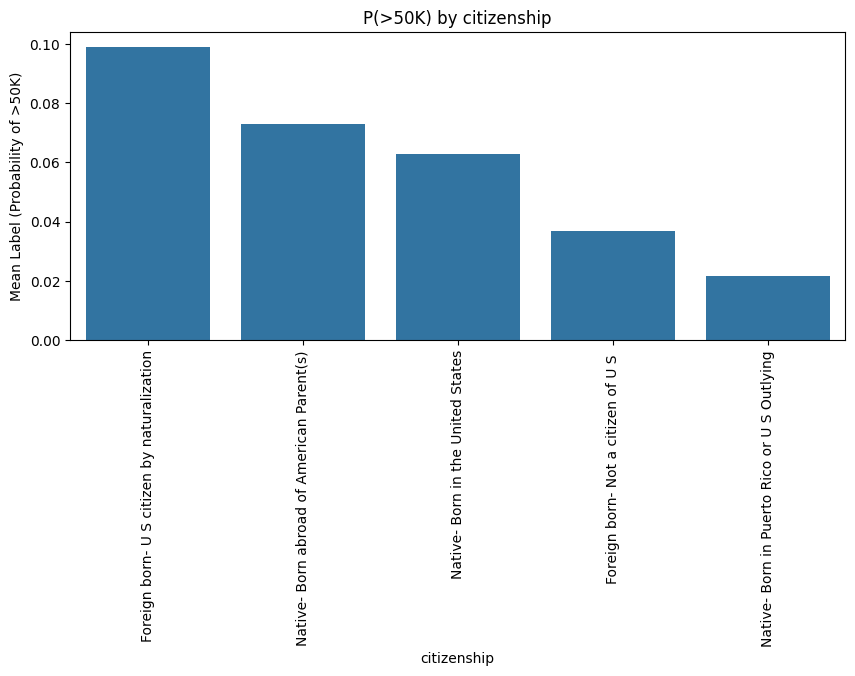

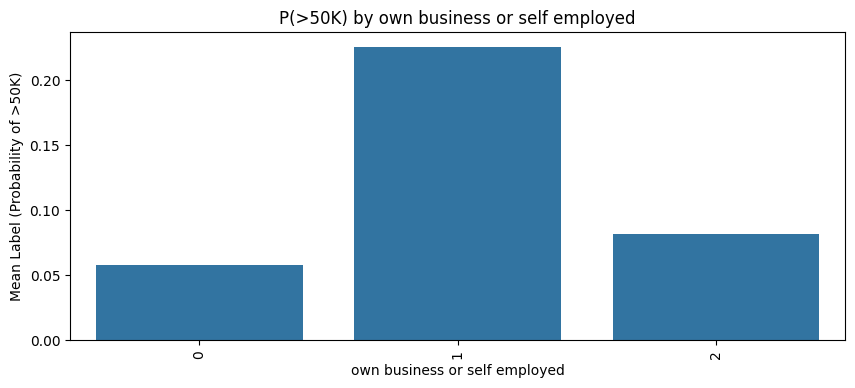

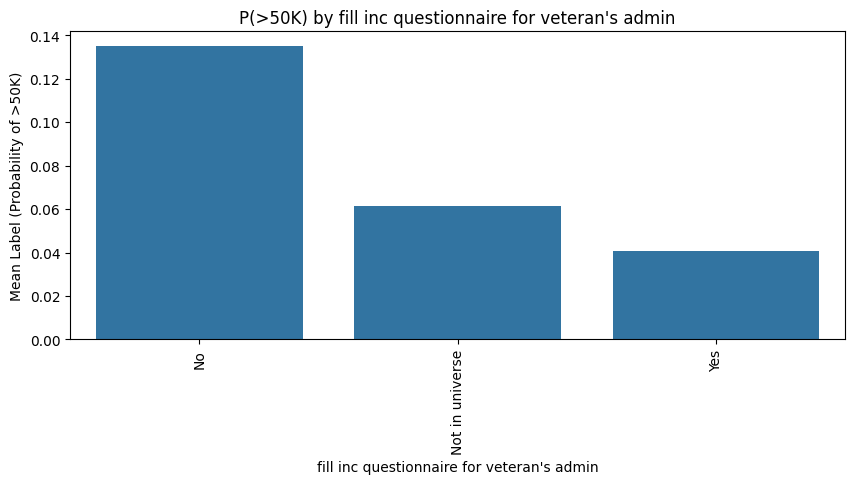

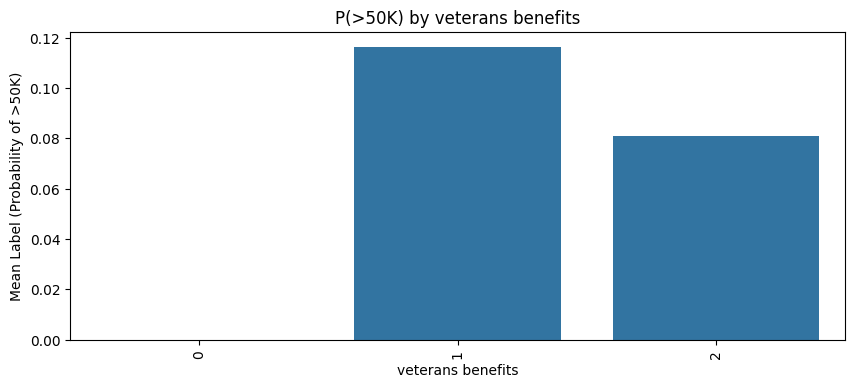

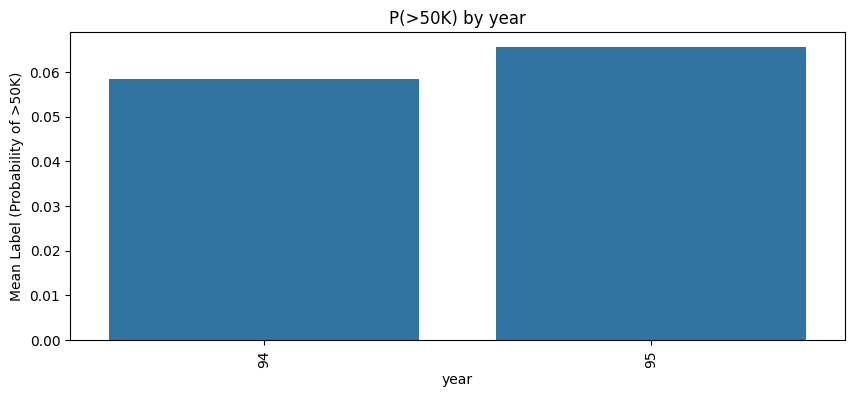

In [58]:
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    
    tmp = df.groupby(col)["label"].mean().sort_values(ascending=False)
    
    sns.barplot(x=tmp.index, y=tmp.values)
    plt.xticks(rotation=90)
    plt.title(f"P(>50K) by {col}")
    plt.ylabel("Mean Label (Probability of >50K)")
    
    plt.show()

In [60]:
df.groupby(col)["label"].std().sort_values(ascending=False)

year
95    0.247635
94    0.234671
Name: label, dtype: float64

In [70]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0


In [71]:
for col in categorical_cols:
    print("\n" + "="*80)
    print(f"Column: {col}")
    print("="*80)
    
    print(df[col].value_counts(dropna=False))


Column: class of worker
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

Column: detailed industry recode
detailed industry recode
0     100684
33     17070
43      8283
4       5984
42      4683
45      4482
29      4209
37      4022
41      3964
32      3596
35      3380
39      2937
34      2765
44      2549
2       2196
11      1764
50      1704
40      1651
47      1644
38      1629
24      1503
12      1350
19      1346
30      1181
31      1178
25      1084
9        993
22       952
36       945
13       899
1        827
48       652
27       626
49       610
3        563
21       559
6        554
5        553
8        55

In [74]:
df = df.replace("?", np.nan)

In [75]:
missing_rate = df.isna().mean().sort_values(ascending=False)
print(missing_rate)

migration prev res in sunbelt                 0.499672
migration code-change in msa                  0.499672
migration code-change in reg                  0.499672
migration code-move within reg                0.499672
country of birth father                       0.033645
country of birth mother                       0.030668
country of birth self                         0.017006
hispanic origin                               0.004380
state of previous residence                   0.003548
age                                           0.000000
major occupation code                         0.000000
major industry code                           0.000000
marital stat                                  0.000000
enroll in edu inst last wk                    0.000000
wage per hour                                 0.000000
education                                     0.000000
detailed occupation recode                    0.000000
detailed industry recode                      0.000000
class of w

In [80]:
drop_cols = missing_rate[missing_rate > 0.4].index.tolist()

keep_unknown_cols = missing_rate[
    (missing_rate > 0) & (missing_rate <= 0.4)
].index.tolist()

In [82]:
df = df.drop(columns = drop_cols)

In [ ]:
df.head()